In [ ]:
Sys.which("R")
.libPaths()

library(Seurat)
library(tidyverse)
library(scales)
library(patchwork)

packageVersion("Seurat")
packageVersion("SeuratObject")
packageVersion("Matrix")


R 
"/nfs/home/students/i.kaciran/.conda/envs/pla_r/bin/R"

[1] "/nfs/home/students/i.kaciran/.conda/envs/pla_r/lib/R/library"

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ ggplot2   3.5.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘scales’


The following object is masked from ‘package:purrr’:

    discard


The following object is masked from ‘package:readr’:

    col_factor




[1] ‘5.3.0’

[1] ‘5.2.0’

[1] ‘1.6.5’

In [ ]:
data_path <- "/nfs/home/students/i.kaciran/FoPra_PLAs/data/datasets/"
output_dir <- "../../results/exploration_week1/"
output_dir_metadata <- "/nfs/home/students/i.kaciran/FoPra_PLAs/data/datasets/metadata_datasets/"


cohort_file <- file.path(output_dir_metadata, "cohort_summary_all.rds")
pla_file <- file.path(output_dir_metadata, "pla_summary_all.rds")
depth_file <- file.path(output_dir_metadata, "library_depth_all.rds")

if (
  file.exists(cohort_file) &&
  file.exists(pla_file) &&
  file.exists(depth_file)
) {
  
  cohort_summary_all <- readRDS(cohort_file)
  pla_summary_all <- readRDS(pla_file)
  library_depth_all <- readRDS(depth_file)
  
} else {
  
  cohort_summary_all <- tibble()
  pla_summary_all <- tibble()
  library_depth_all <- tibble()
}

In [202]:
# "gated_ImmuneAging.rds", "gated_heart_processed.rds", "gated_sepsis_processed.rds", "gated_vaccine_processed.rds", "gated_our_dataset_processed.rds"
#file_name <- "gated_ImmuneAging.rds"
#file_name <- "gated_heart_processed.rds" 
#file_name <- "gated_sepsis_processed.rds" 
#file_name <- "gated_vaccine_processed.rds" 
file_name <- "gated_our_dataset_processed.rds" 


if (file_name == "gated_ImmuneAging.rds"){
    dataset_type <- "immune_aging"
} else if (file_name == "gated_heart_processed.rds"){
    dataset_type <- "heart"
} else if (file_name == "gated_sepsis_processed.rds"){
    dataset_type <- "sepsis"
} else if (file_name == "gated_vaccine_processed.rds"){
    dataset_type <- "vaccine"
} else if (file_name == "gated_our_dataset_processed.rds"){
    dataset_type <- "our_data"
}


In [203]:
# Load data
seurat_obj <- readRDS(paste0(data_path, file_name))
metadata <- seurat_obj@meta.data
clean_name <- str_remove(file_name, "\\.rds$")
dir.create(output_dir, showWarnings = FALSE, recursive = TRUE)
print(colnames(metadata))
#table(metadata$nCount_RNA)

 [1] "orig.ident"          "nCount_RNA"          "nFeature_RNA"       
 [4] "sample_ID"           "barcode"             "sample_all"         
 [7] "patient"             "condition_all"       "condition"          
[10] "study"               "origin"              "timepoint"          
[13] "sequenced"           "multiplexing"        "sample_nr"          
[16] "GEM"                 "sorted_celltype"     "batch"              
[19] "nCount_ADT"          "nFeature_ADT"        "percent.mt"         
[22] "percent.ribo"        "percent.hb"          "mt_outlier_all"     
[25] "is_outlier_RNA"      "is_outlier_protein"  "is_outlier"         
[28] "scDblFinder.class"   "scDblFinder.score"   "RNA_snn_res.0.8"    
[31] "seurat_clusters"     "RNA_snn_res.0.25"    "RNA.weight"         
[34] "ADT.weight"          "leiden_0.8_totalVI"  "leiden_0.25_totalVI"
[37] "celltype_full"       "lineage"             "pla_status"         
[40] "celltype"           


In [204]:
if (dataset_type == "immune_aging" & "disease" %in% colnames(metadata)) {
  metadata <- metadata %>%
    mutate(cohort = if_else(str_detect(tolower(disease), "healthy|normal|control"), "healthy", "diseased"))

} else if (dataset_type == "heart" & "HF.etiology" %in% colnames(metadata)) {
  metadata <- metadata %>%
    mutate(cohort = if_else(tolower(HF.etiology) == "donor", "healthy", "diseased"))

} else if (dataset_type == "sepsis" & "Group" %in% colnames(metadata)) {
  metadata <- metadata %>%
    mutate(cohort = if_else(Group == "Adult Healthy Control", "healthy", "diseased"))

} else if (dataset_type == "vaccine" & "time" %in% colnames(metadata)) {
  metadata <- metadata %>%
    mutate(cohort = if_else(time == 0, "healthy", "diseased"))

} else if (dataset_type == "our_data" & "condition" %in% colnames(metadata)) {
  metadata <- metadata %>%
    mutate(cohort = if_else(condition == "Healthy", "healthy", "diseased"))

} 

seurat_obj@meta.data$cohort <- metadata$cohort

In [205]:
metadata_whole_plot <- metadata %>%
  mutate(
    cohort = as.character(cohort),
    dataset = dataset_type
  )

In [206]:
cohort_summary <- metadata_whole_plot %>%
  count(dataset, cohort, name = "n_cells")

cohort_summary_all <- bind_rows(
  cohort_summary_all,
  cohort_summary
)

In [207]:
# Celltype and PLA Columns
cell_col <- case_when(
  "celltype_clean" %in% colnames(metadata) ~ "celltype_clean",
  "celltype" %in% colnames(metadata) ~ "celltype",
  TRUE ~ NA_character_
)

lineage_col <- case_when(
  "lineage" %in% colnames(metadata_whole_plot) ~ "lineage",
  "Lineage" %in% colnames(metadata_whole_plot) ~ "Lineage",
  "cell_lineage" %in% colnames(metadata_whole_plot) ~ "cell_lineage",
  TRUE ~ NA_character_

)

pla_col <- case_when(
  "pla_status" %in% colnames(metadata) ~ "pla_status",
  "PLA_status" %in% colnames(metadata) ~ "PLA_status",
  TRUE ~ NA_character_
)

In [208]:
if (!is.na(lineage_col) && !is.na(pla_col)) {
  
  pla_summary <- metadata_whole_plot %>%
    group_by(
      dataset,
      cohort,
      lineage = .data[[lineage_col]]
    ) %>%
    summarise(
      n_cells = n(),
      n_PLA = sum(
        tolower(as.character(.data[[pla_col]])) == "pla",
        na.rm = TRUE
      ),
      PLA_rate = mean(
        tolower(as.character(.data[[pla_col]])) == "pla",
        na.rm = TRUE
      ),
      .groups = "drop"
    )
  
  pla_summary_all <- bind_rows(
    pla_summary_all,
    pla_summary
  )
  
} else {
  message("PLA or lineage column not found")
}

In [209]:
if ("nCount_RNA" %in% colnames(metadata_whole_plot)) {
  
  set.seed(123)
  
  library_depth <- metadata_whole_plot %>%
  select(dataset, cohort, nCount_RNA) %>%
  filter(
    !is.na(cohort),
    !is.na(nCount_RNA),
    nCount_RNA > 0
  )

  library_depth_all <- bind_rows(
    library_depth_all,
    library_depth
  )
}

In [ ]:
saveRDS(
  cohort_summary_all,
  file.path(output_dir_metadata, "cohort_summary_all.rds")
)

saveRDS(
  pla_summary_all,
  file.path(output_dir_metadata, "pla_summary_all.rds")
)

saveRDS(
  library_depth_all,
  file.path(output_dir_metadata, "library_depth_all.rds")
)

In [230]:
cohort_colors <- c(
  "healthy" = "#00bfc4",
  "diseased" = "#f8766d"
)

pla_summary_plot <- pla_summary_all %>%
  mutate(
    dataset = factor(
      dataset,
      levels = c(
        "heart",
        "immune_aging",
        "our_data",
        "sepsis",
        "vaccine"
      )
    )
  )

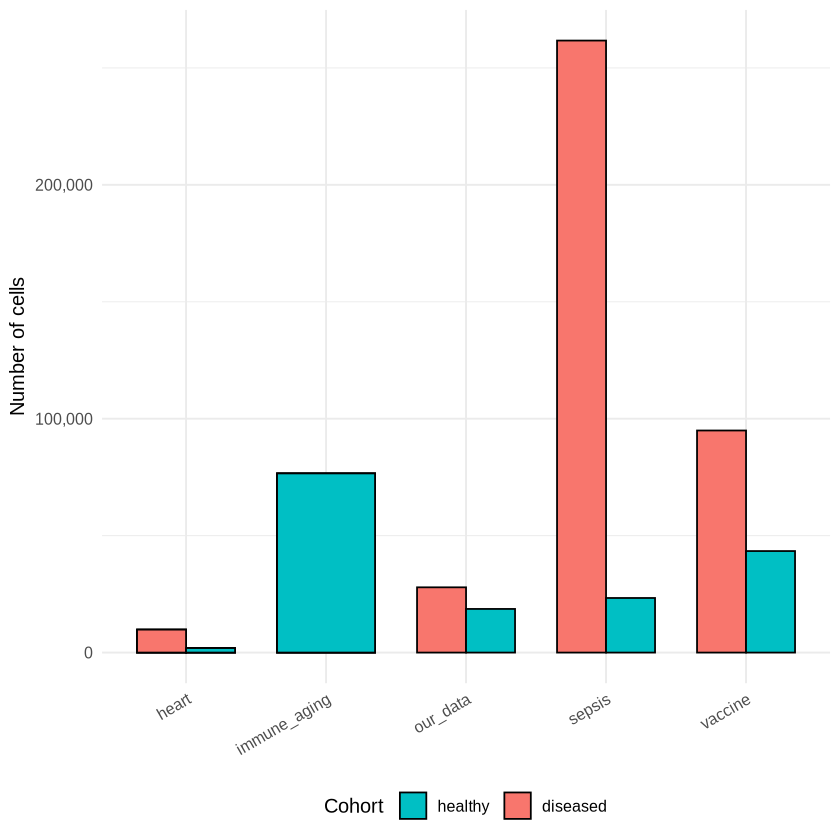

In [212]:
p_cohort <- ggplot(
  cohort_summary_all,
  aes(x = dataset, y = n_cells, fill = cohort)
) +
  geom_col(
    position = "dodge",
    color = "black",
    width = 0.7
  ) +
  cohort_scale +
  scale_y_continuous(labels = scales::comma) +
  theme_minimal(base_size = 12) +
  theme(
    plot.title = element_blank(),
    axis.text.x = element_text(
      angle = 30,
      hjust = 1
    ),
    legend.position = "bottom"
  ) +
  labs(
    x = NULL,
    y = "Number of cells",
    fill = "Cohort"
  )

  print(p_cohort)

ggsave(
  file.path(output_dir, "cohort_distrib.png"),
  plot = p_cohort,
  width = 16,
  height = 11,
  dpi = 300
)

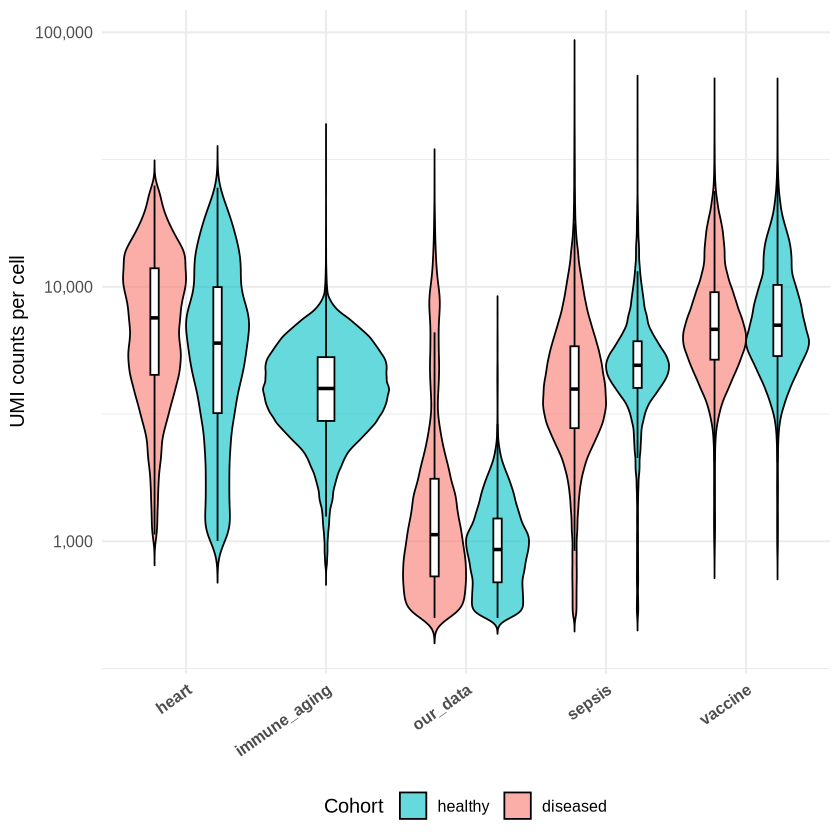

In [213]:
p_library <- ggplot(
  library_depth_all,
  aes(
    x = dataset,
    y = nCount_RNA,
    fill = cohort,
    group = interaction(dataset, cohort)
  )
) +
  geom_violin(
    position = position_dodge(width = 0.9),
    alpha = 0.6,
    trim = FALSE,
    color = "black",
    scale = "width"
  ) +
  geom_boxplot(
    position = position_dodge(width = 0.9),
    width = 0.12,
    fill = "white",
    outlier.shape = NA,
    color = "black"
  ) +
  scale_y_log10(labels = scales::comma) +
  cohort_scale +
  theme_minimal(base_size = 12) +
  theme(
    plot.title = element_blank(),
    axis.text.x = element_text(
      angle = 35,
      hjust = 1,
      face = "bold"
    ),
    legend.position = "bottom"
  ) +
  labs(
    x = NULL,
    y = "UMI counts per cell",
    fill = "Cohort"
  )

  print(p_library)

ggsave(
  file.path(output_dir, "library_depth.png"),
  plot = p_library,
  width = 16,
  height = 11,
  dpi = 300
)

Warning message:
“Removed 38 rows containing missing values or values outside the scale range
(`geom_col()`).”
Warning message:
“Removed 38 rows containing missing values or values outside the scale range
(`geom_col()`).”


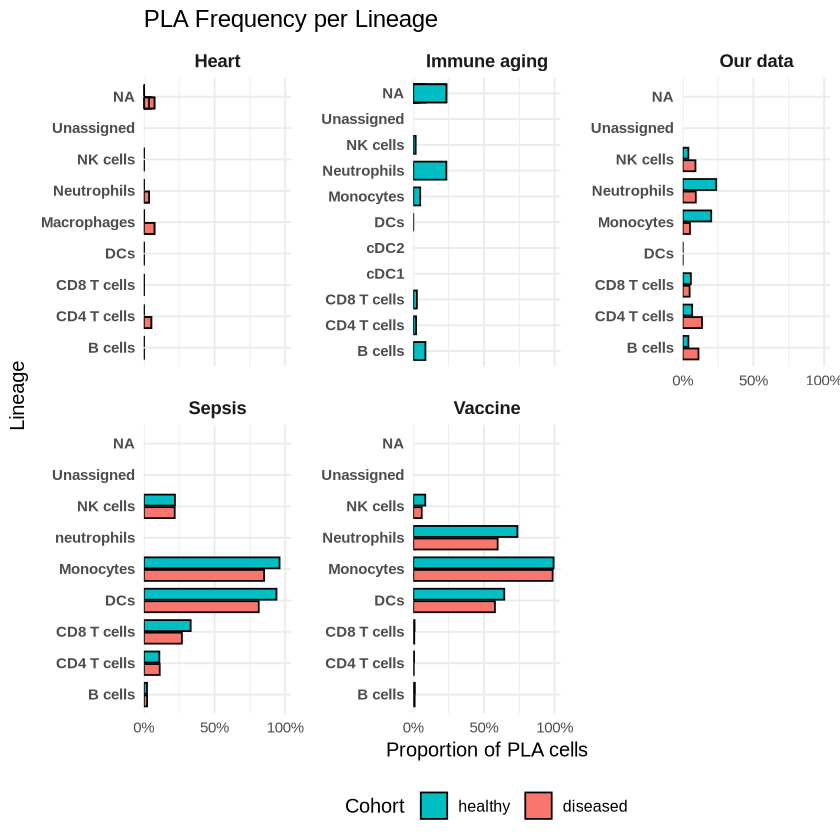

In [231]:
p_pla <- ggplot(
  pla_summary_plot,
  aes(
    x = PLA_rate,
    y = lineage,
    fill = cohort
  )
) +
  geom_col(
    position = position_dodge(width = 0.8),
    width = 0.7,
    color = "black"
  ) +
  facet_wrap(
    ~ dataset,
    ncol = 3,
    scales = "free_y",
    labeller = labeller(
      dataset = c(
        "heart" = "Heart",
        "immune_aging" = "Immune aging",
        "our_data" = "Our data",
        "sepsis" = "Sepsis",
        "vaccine" = "Vaccine"
      )
    )
  ) +
  scale_x_continuous(
    labels = scales::label_percent(accuracy = 1),
    breaks = scales::breaks_pretty(n = 3),
    expand = expansion(mult = c(0, 0.05))
  ) +
  scale_fill_manual(
    values = cohort_colors,
    breaks = c("healthy", "diseased")
  ) +
  theme_minimal(base_size = 12) +
  theme(
    axis.text.y = element_text(
      face = "bold",
      size = 9
    ),
    axis.text.x = element_text(size = 9),
    strip.text = element_text(
      face = "bold",
      size = 11
    ),
    panel.spacing = unit(1, "lines"),
    legend.position = "bottom"
  ) +
  labs(
    title = "PLA Frequency per Lineage",
    x = "Proportion of PLA cells",
    y = "Lineage",
    fill = "Cohort"
  )

print(p_pla)

ggsave(
  file.path(output_dir, "pla_freq_per_lineage.png"),
  plot = p_pla,
  width = 16,
  height = 11,
  dpi = 300
)

In [232]:
p_cohort <- p_cohort +
  labs(title = "Cohort distribution") +
  theme(plot.title = element_text(face = "bold", size = 13))

p_library <- p_library +
  labs(title = "Library depth") +
  theme(plot.title = element_text(face = "bold", size = 13))

p_pla <- p_pla +
  labs(title = "PLA frequency per lineage") +
  theme(plot.title = element_text(face = "bold", size = 13))

p_cohort <- p_cohort +
  theme(legend.position = "none")

p_library <- p_library +
  theme(legend.position = "none")

p_pla <- p_pla +
  theme(legend.position = "bottom")

Warning message:
“Removed 38 rows containing missing values or values outside the scale range
(`geom_col()`).”
Warning message:
“Removed 38 rows containing missing values or values outside the scale range
(`geom_col()`).”


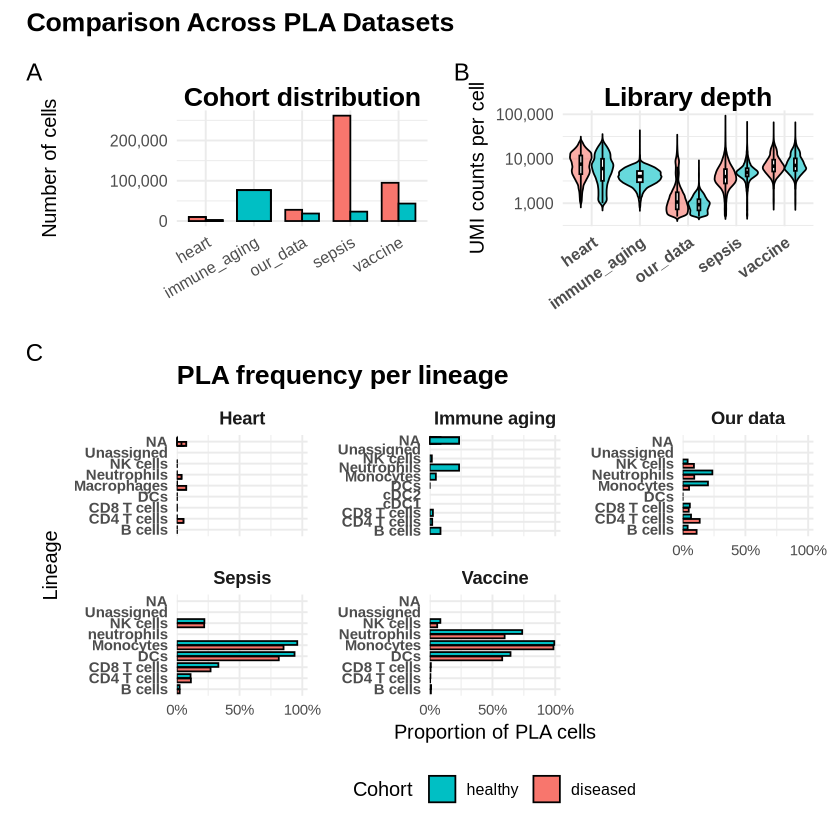

In [233]:
top_row <- p_cohort | p_library

combined_plot <- top_row / p_pla +
  plot_layout(
    heights = c(0.8, 1.8)
  ) +
  plot_annotation(
    title = "Comparison Across PLA Datasets",
    tag_levels = "A"
  ) &
  theme(
    plot.title = element_text(
      face = "bold",
      size = 16
    ),
    plot.margin = margin(8, 8, 8, 8)
  )

print(combined_plot)

ggsave(
  file.path(output_dir, "all_dataset_comparison_wide.png"),
  plot = combined_plot,
  width = 16,
  height = 12,
  dpi = 300
)

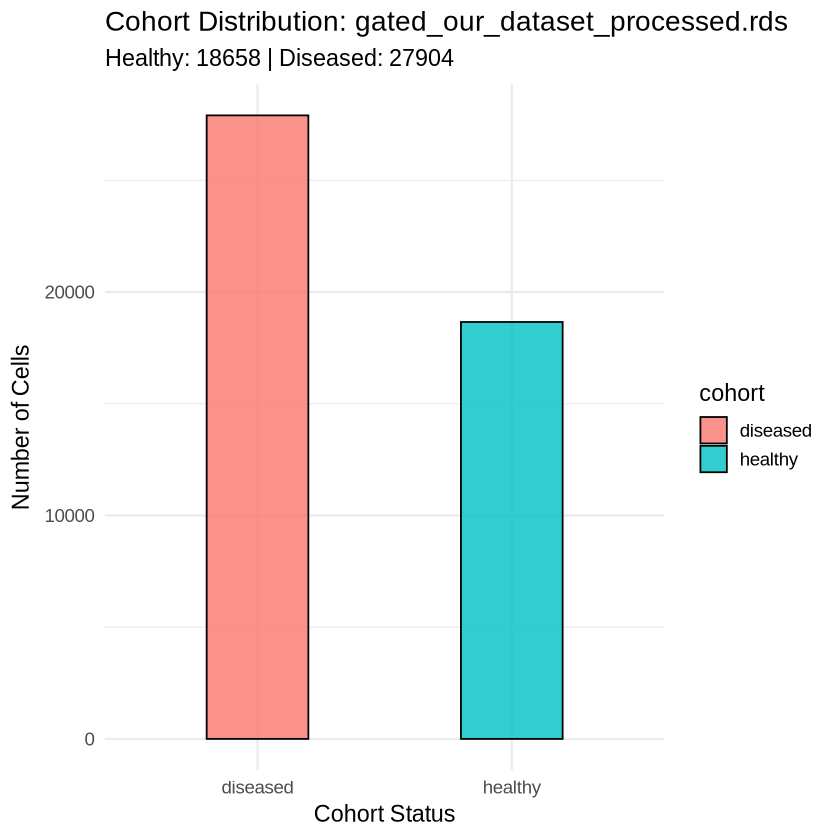

In [217]:
# PLOT 1: Cohort distribution
p1 <- ggplot(metadata, aes(x = cohort, fill = cohort)) +
  geom_bar(alpha = 0.8, color = "black", width = 0.4) +
  scale_fill_manual(values = c("healthy" = "#00bfc4", "diseased" = "#f8766d")) +
  theme_minimal(base_size = 14) +
  labs(
    title = paste("Cohort Distribution:", file_name),
    subtitle = paste("Healthy:", sum(metadata$cohort == "healthy"), "| Diseased:", sum(metadata$cohort == "diseased")),
    x = "Cohort Status", y = "Number of Cells"
  )
print(p1)
ggsave(paste0(output_dir, "cohort_dist_", clean_name, ".png"), plot = p1, width = 6, height = 5, dpi = 300)

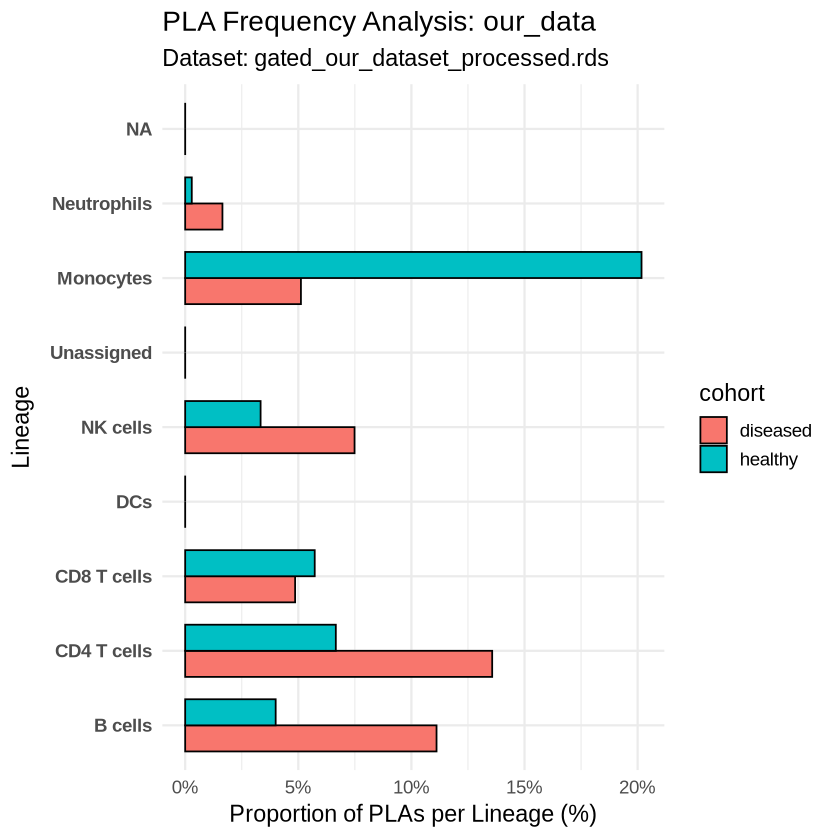

In [218]:
# PLOT 2: PLA frequency per celltype
if (!is.na(lineage_col) & !is.na(pla_col)) {
  pla_freq <- metadata %>%
    group_by(!!sym(lineage_col), cohort) %>%
    summarise(
      PLA_rate = sum(tolower(!!sym(pla_col)) == "pla", na.rm = TRUE) / n(),
      .groups = "drop"
    )
  
  p2 <- ggplot(pla_freq, aes(y = !!sym(lineage_col), x = PLA_rate, fill = cohort)) +
    geom_bar(stat = "identity", position = "dodge", color = "black", width = 0.7) +
    scale_x_continuous(labels = scales::percent_format()) +
    scale_fill_manual(values = c("healthy" = "#00bfc4", "diseased" = "#f8766d")) +
    theme_minimal(base_size = 14) +
    theme(axis.text.y = element_text(face = "bold")) +
    labs(
      title = paste("PLA Frequency Analysis:", dataset_type),
      subtitle = paste("Dataset:", file_name),
      x = "Proportion of PLAs per Lineage (%)", y = "Lineage"
    )
  print(p2)
  ggsave(paste0(output_dir, "pla_frequency_", clean_name, ".png"), plot = p2, width = 11, height = 7, dpi = 300)
} else {
  print("PLA or Lineage not found")
}

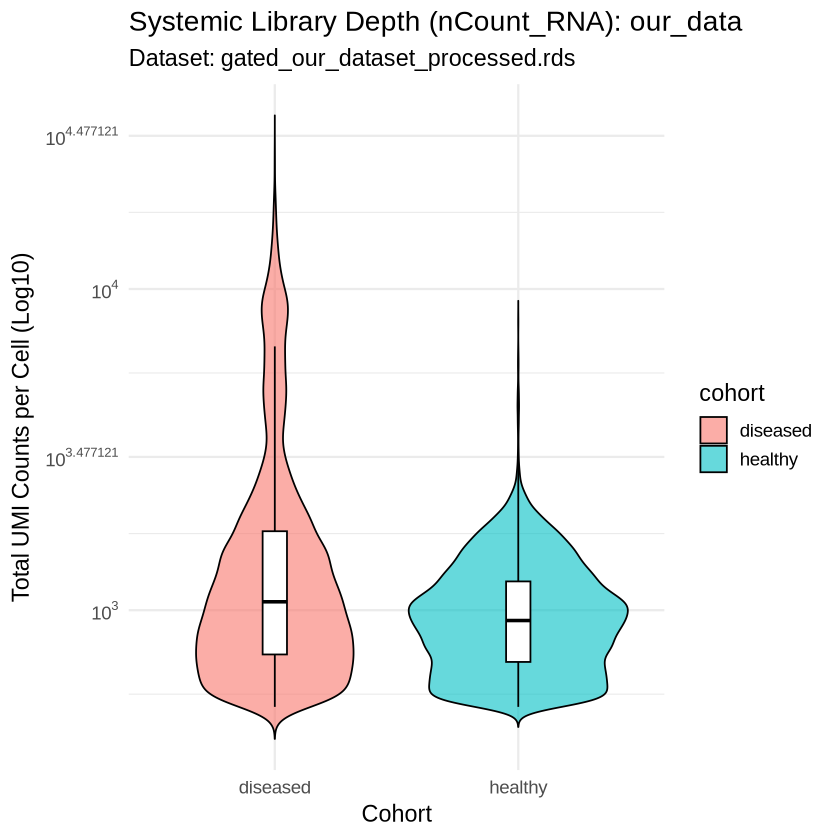

In [219]:
# PLOT 3: Sequencing depth
if ("nCount_RNA" %in% colnames(metadata)) {
  p3 <- ggplot(metadata, aes(x = cohort, y = nCount_RNA, fill = cohort)) +
    geom_violin(alpha = 0.6, trim = FALSE, color = "black") +
    geom_boxplot(width = 0.1, fill = "white", outlier.shape = NA, color = "black") +
    scale_y_log10(labels = scales::trans_format("log10", scales::math_format(10^.x))) +
    scale_fill_manual(values = c("healthy" = "#00bfc4", "diseased" = "#f8766d")) +
    theme_minimal(base_size = 14) +
    labs(
      title = paste("Systemic Library Depth (nCount_RNA):", dataset_type),
      subtitle = paste("Dataset:", file_name),
      x = "Cohort", y = "Total UMI Counts per Cell (Log10)"
    )
  print(p3)
  ggsave(paste0(output_dir, "library_depth_", clean_name, ".png"), plot = p3, width = 7, height = 5, dpi = 300)
}

In [220]:
# Demography exploration
if ("Age" %in% colnames(metadata)) { 
    metadata$Explor_Age <- as.numeric(metadata$Age) 
} else if ("donor_age" %in% colnames(metadata)) { 
    metadata$Explor_Age <- as.numeric(metadata$donor_age) 
} else { 
    metadata$Explor_Age <- NA 
}

if ("Sex" %in% colnames(metadata)) { 
    metadata$Explor_Sex <- as.character(metadata$Sex) 
} else if ("Gender" %in% colnames(metadata)) { 
    metadata$Explor_Sex <- as.character(metadata$Gender) 
} else if ("sex" %in% colnames(metadata)) { 
    metadata$Explor_Sex <- as.character(metadata$sex) 
} else { 
    metadata$Explor_Sex <- NA 
}

if (!all(is.na(metadata$Explor_Age))) {
  p_age <- ggplot(metadata, aes(x = cohort, y = Explor_Age, fill = cohort)) +
    geom_boxplot(alpha = 0.7, outlier.shape = 16, outlier.size = 1) +
    scale_fill_manual(values = c("healthy" = "#00bfc4", "diseased" = "#f8766d")) +
    theme_minimal(base_size = 14) +
    labs(title = paste("Age Distribution:", file_name), x = "Cohort", y = "Age (Years)")
  print(p_age)
  ggsave(paste0(output_dir, "demo_age_", clean_name, ".png"), plot = p_age, width = 5, height = 5, dpi = 300)
}

if (!all(is.na(metadata$Explor_Sex))) {
  p_sex <- ggplot(metadata, aes(x = cohort, fill = Explor_Sex)) +
    geom_bar(position = "fill", color = "black", alpha = 0.8) +
    scale_y_continuous(labels = scales::percent_format()) +
    scale_fill_brewer(palette = "Pastel1") +
    theme_minimal(base_size = 14) +
    labs(title = paste("Sex Composition:", file_name), x = "Cohort", y = "Proportion (%)", fill = "Sex")
  print(p_sex)
  ggsave(paste0(output_dir, "demo_sex_", clean_name, ".png"), plot = p_sex, width = 5, height = 5, dpi = 300)
}

In [221]:
# Special Age plot for immune aging
if ("donor_age" %in% colnames(metadata)) {
  
  metadata_clean <- metadata %>% filter(!is.na(donor_age) & donor_age != "unknown")
 
  metadata_clean$donor_age <- factor(metadata_clean$donor_age, 
                                   levels = sort(unique(metadata_clean$donor_age)))

  p_age <- ggplot(metadata_clean, aes(x = donor_age, fill = cohort)) +
  geom_bar(position = "dodge", color = "black", alpha = 0.8, width = 0.7) +
  scale_fill_manual(values = c("healthy" = "#00bfc4", "diseased" = "#f8766d")) +
  theme_minimal(base_size = 14) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, face = "bold"), # Schräge Schrift für perfekte Lesbarkeit
    panel.grid.major.x = element_blank(),
    legend.position = "bottom"
  ) +
  labs(
    title = "Age Cohorts Distribution (ImmuneAging)",
    subtitle = paste("Dataset:", file_name, "| Total Cells:", nrow(metadata_clean)),
    x = "Age Category", 
    y = "Number of Cells",
    fill = "Cohort Status"
  )
  
  print(p_age)
  ggsave(paste0(output_dir, "demo_age_categories_", clean_name, ".png"), plot = p_age, width = 8, height = 5, dpi = 300)
} else {
  print(paste("Keine Altersdaten im Datensatz", file_name, "verfügbar."))
}

[1] "Keine Altersdaten im Datensatz gated_our_dataset_processed.rds verfügbar."


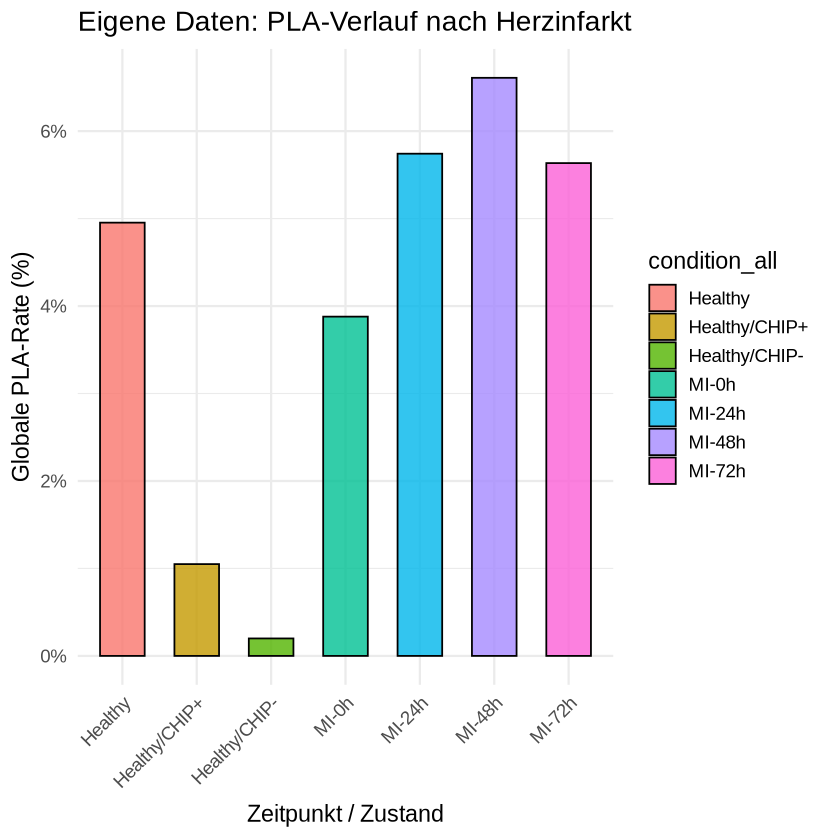

In [222]:
# Special plots
if (dataset_type == "our_data" & "condition_all" %in% colnames(metadata)) {
  
  kinetic_data <- metadata %>%
    filter(str_detect(condition_all, "MI|Healthy")) %>%
    group_by(condition_all) %>%
    summarise(PLA_rate = sum(tolower(!!sym(pla_col)) == "pla", na.rm = TRUE) / n(), .groups = "drop")
  
  p_spec <- ggplot(kinetic_data, aes(x = condition_all, y = PLA_rate, fill = condition_all)) +
    geom_bar(stat = "identity", color = "black", alpha = 0.8, width = 0.6) +
    scale_y_continuous(labels = scales::percent_format()) +
    theme_minimal(base_size = 14) +
    theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
    labs(title = "Eigene Daten: PLA-Verlauf nach Herzinfarkt", x = "Zeitpunkt / Zustand", y = "Globale PLA-Rate (%)")
  print(p_spec)
  ggsave(paste0(output_dir, "spec_kinetics_", clean_name, ".png"), plot = p_spec, width = 7, height = 5, dpi = 300)

} else if (dataset_type == "sepsis" & "SOFA.score" %in% colnames(metadata)) {
  
  sepsis_data <- metadata %>%
    mutate(SOFA_Group = case_when(SOFA.score <= 5 ~ "Mild (0-5)", SOFA.score <= 10 ~ "Moderate (6-10)", TRUE ~ "Severe (11+)")) %>%
    filter(!is.na(SOFA.score))
  
  p_spec <- ggplot(sepsis_data, aes(x = SOFA_Group, y = nCount_RNA, fill = SOFA_Group)) +
    geom_violin(alpha = 0.7, trim = FALSE) +
    geom_boxplot(width = 0.1, fill = "white", outlier.shape = NA) +
    scale_y_log10(labels = scales::trans_format("log10", scales::math_format(10^.x))) +
    scale_fill_brewer(palette = "Oranges") +
    theme_minimal(base_size = 14) +
    labs(title = "Sepsis: Library Depth vs. Organ Failure (SOFA)", x = "SOFA Severity Group", y = "nCount_RNA (Log10)")
  print(p_spec)
  ggsave(paste0(output_dir, "spec_sofa_", clean_name, ".png"), plot = p_spec, width = 7, height = 5, dpi = 300)

} else if (dataset_type == "vaccine" & "Phase" %in% colnames(metadata)) {
  
  p_spec <- ggplot(metadata, aes(x = as.factor(time), fill = Phase)) +
    geom_bar(position = "fill", color = "black", alpha = 0.8, width = 0.6) +
    scale_y_continuous(labels = scales::percent_format()) +
    scale_fill_brewer(palette = "Set2") +
    theme_minimal(base_size = 14) +
    labs(title = "Vaccine: Cell Cycle Shift after Vaccination", x = "Days post Vaccination", y = "Proportion of Cells (%)", fill = "Cell Cycle Phase")
  print(p_spec)
  ggsave(paste0(output_dir, "spec_cellcycle_", clean_name, ".png"), plot = p_spec, width = 6, height = 5, dpi = 300)

} else if (dataset_type == "heart" & "HF.etiology" %in% colnames(metadata)) {
  
  p_spec <- ggplot(metadata, aes(x = HF.etiology, y = nCount_RNA, fill = HF.etiology)) +
    geom_boxplot(alpha = 0.7, outlier.shape = 16, outlier.size = 0.5) +
    scale_y_log10(labels = scales::trans_format("log10", scales::math_format(10^.x))) +
    theme_minimal(base_size = 14) +
    labs(title = "Heart: Library Depth Across All Etiologies", x = "Detailed Etiology", y = "nCount_RNA (Log10)") +
    theme(legend.position = "none")
  print(p_spec)
  ggsave(paste0(output_dir, "spec_etiologies_", clean_name, ".png"), plot = p_spec, width = 7, height = 5, dpi = 300)
}

# Extra Plots for Immune Dataset

In [223]:
if (dataset_type == "immune_aging") {

  # Raucher vs Nicht-Raucher
  metadata_smoke <- metadata %>%
    filter(donor_smoking_status %in% c("current", "never"))

  pla_smoke <- metadata_smoke %>%
    group_by(celltype, donor_smoking_status) %>%
    summarise(
      PLA_rate = sum(tolower(pla_status) == "pla", na.rm = TRUE) / n(),
      .groups = "drop"
    )

  p_smoke <- ggplot(pla_smoke, aes(y = celltype, x = PLA_rate, fill = donor_smoking_status)) +
    geom_bar(stat = "identity", position = "dodge", color = "black", width = 0.7) +
    scale_x_continuous(labels = scales::percent_format()) +
    scale_fill_manual(values = c("current" = "#f8766d", "never" = "#00bfc4")) +
    theme_minimal(base_size = 14) +
    labs(
      title = "ImmuneAging: Impact of Smoking on PLA Frequency",
      x = "PLA Rate (%)", y = "Cell Type", fill = "Smoking Status"
    )
  print(p_smoke)
  ggsave(paste0(output_dir, "spec_smoking_pla_", clean_name, ".png"), plot = p_smoke, width = 9, height = 6, dpi = 300)


  # --- Todesursache vs. PLA-rate ---
  metadata_death <- metadata %>%
    filter(donor_cause_of_death != "unknown")

  pla_death <- metadata_death %>%
    group_by(donor_cause_of_death) %>%
    summarise(
      PLA_rate = sum(tolower(pla_status) == "pla", na.rm = TRUE) / n(),
      .groups = "drop"
    )

  p_death <- ggplot(pla_death, aes(x = reorder(donor_cause_of_death, -PLA_rate), y = PLA_rate, fill = donor_cause_of_death)) +
    geom_bar(stat = "identity", color = "black", alpha = 0.8, width = 0.6) +
    scale_y_continuous(labels = scales::percent_format()) +
    theme_minimal(base_size = 14) +
    theme(axis.text.x = element_text(angle = 45, hjust = 1, face = "bold"), legend.position = "none") +
    labs(
      title = "ImmuneAging: PLA Frequency across Causes of Death",
      subtitle = "Post-mortem artifact and cell-stress analysis",
      x = "Cause of Death", y = "Global PLA Rate (%)"
    )
  print(p_death)
  ggsave(paste0(output_dir, "spec_cause_of_death_pla_", clean_name, ".png"), plot = p_death, width = 8, height = 6, dpi = 300)}

In [224]:
print(colnames(metadata))

 [1] "orig.ident"          "nCount_RNA"          "nFeature_RNA"       
 [4] "sample_ID"           "barcode"             "sample_all"         
 [7] "patient"             "condition_all"       "condition"          
[10] "study"               "origin"              "timepoint"          
[13] "sequenced"           "multiplexing"        "sample_nr"          
[16] "GEM"                 "sorted_celltype"     "batch"              
[19] "nCount_ADT"          "nFeature_ADT"        "percent.mt"         
[22] "percent.ribo"        "percent.hb"          "mt_outlier_all"     
[25] "is_outlier_RNA"      "is_outlier_protein"  "is_outlier"         
[28] "scDblFinder.class"   "scDblFinder.score"   "RNA_snn_res.0.8"    
[31] "seurat_clusters"     "RNA_snn_res.0.25"    "RNA.weight"         
[34] "ADT.weight"          "leiden_0.8_totalVI"  "leiden_0.25_totalVI"
[37] "celltype_full"       "lineage"             "pla_status"         
[40] "celltype"            "cohort"              "Explor_Age"         
[43] "

In [225]:

# Log scale for age plot 
if ("Age_Num" %in% colnames(metadata) && !all(is.na(metadata$Age_Num))) {
  pla_age_trend <- metadata %>%
    filter(!is.na(Age_Num)) %>%
    group_by(Age_Num, celltype) %>%
    summarise(PLA_rate = sum(tolower(pla_status) == "pla", na.rm = TRUE) / n(), .groups = "drop") %>%
    filter(celltype %in% names(sort(table(metadata$celltype), decreasing = TRUE)[1:4]))

  p_aging_trend <- ggplot(pla_age_trend, aes(x = Age_Num, y = PLA_rate, color = celltype)) +
    geom_point(alpha = 0.6, size = 2.5) +
    geom_smooth(method = "lm", se = FALSE, size = 1.2) +
    # Der Trick: Wir begrenzen die Ansicht auf 0-30%, um die Mehrheit der Daten zu zeigen, 
    # erwähnen den Ausreißer aber auf der Slide!
    coord_cartesian(ylim = c(0, 0.30)) + 
    scale_y_continuous(labels = scales::percent_format()) +
    scale_color_brewer(palette = "Set1") +
    theme_minimal(base_size = 14) +
    labs(
      title = "ImmuneAging: PLA Trends (Focused View 0-30%)",
      subtitle = "Note: Rare single outliers at 50% and 90% are clipped for visual clarity",
      x = "Age of Donor (Years)", y = "PLA Rate (%)", color = "Cell Type"
    )
  print(p_aging_trend)
  ggsave(paste0(output_dir, "spec_aging_trend_pla_FIXED.png"), plot = p_aging_trend, width = 8, height = 5, dpi = 300)



metadata_comp <- metadata %>%
  filter(!is.na(Age_Num)) %>%
  mutate(Age_Group = case_when(
    Age_Num < 40 ~ "Young (20-39)",
    Age_Num < 60 ~ "Middle (40-59)",
    TRUE ~ "Senior (60+)"
  ))

# nur top 6 häufigsten zelltypen, rest in other
top_cells <- names(sort(table(metadata_comp$celltype), decreasing = TRUE)[1:6])
metadata_comp <- metadata_comp %>%
  mutate(celltype_grouped = if_else(celltype %in% top_cells, celltype, "Other"))

p_comp <- ggplot(metadata_comp, aes(x = Age_Group, fill = celltype_grouped)) +
  geom_bar(position = "fill", color = "black", alpha = 0.8, width = 0.6) +
  scale_y_continuous(labels = scales::percent_format()) +
  scale_fill_brewer(palette = "Set3") +
  theme_minimal(base_size = 14) +
  labs(
    title = "ImmuneAging: Main Cell Type Shifts by Generation",
    x = "Age Group", y = "Proportion of Total Cells (%)", fill = "Main Cell Types"
  )
print(p_comp)
ggsave(paste0(output_dir, "spec_cell_composition_FIXED.png"), plot = p_comp, width = 8, height = 6, dpi = 300)}

# Extra Plots for Sepsis & Vaccine Dataset

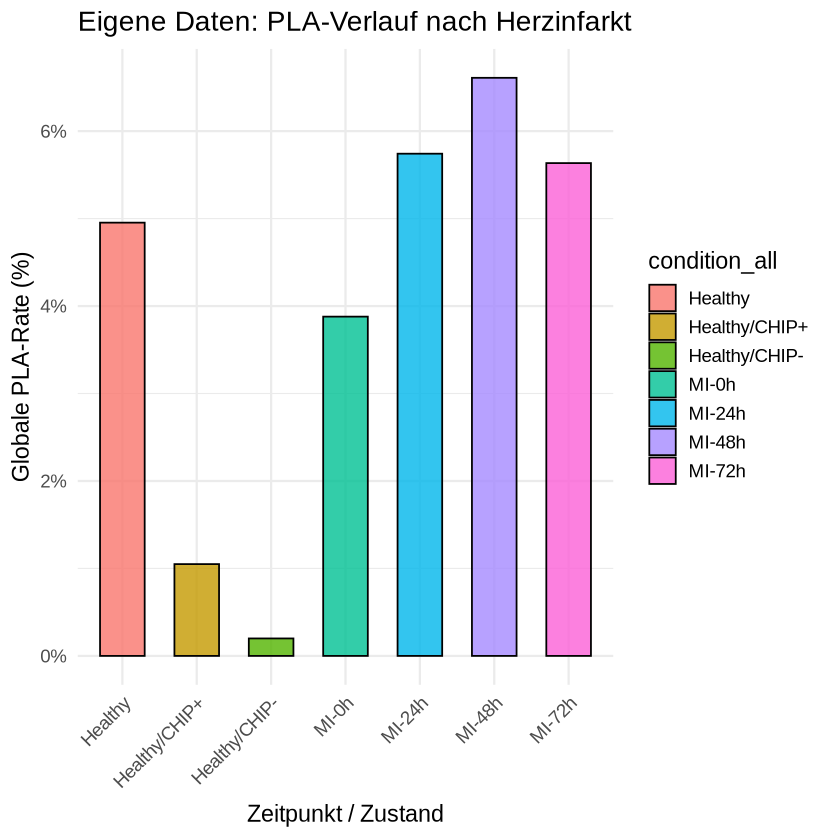

In [226]:
if (dataset_type == "our_data" & "condition_all" %in% colnames(metadata)) {
  
  kinetic_data <- metadata %>%
    filter(str_detect(condition_all, "MI|Healthy")) %>%
    group_by(condition_all) %>%
    summarise(PLA_rate = sum(tolower(!!sym(pla_col)) == "pla", na.rm = TRUE) / n(), .groups = "drop")
  
  p_spec <- ggplot(kinetic_data, aes(x = condition_all, y = PLA_rate, fill = condition_all)) +
    geom_bar(stat = "identity", color = "black", alpha = 0.8, width = 0.6) +
    scale_y_continuous(labels = scales::percent_format()) +
    theme_minimal(base_size = 14) +
    theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
    labs(title = "Eigene Daten: PLA-Verlauf nach Herzinfarkt", x = "Zeitpunkt / Zustand", y = "Globale PLA-Rate (%)")
  print(p_spec)
  ggsave(paste0(output_dir, "spec_kinetics_", clean_name, ".png"), plot = p_spec, width = 7, height = 5, dpi = 300)

} else if (dataset_type == "sepsis" & "Group" %in% colnames(metadata)) {
  
  # PLA frequency by group
  pla_group <- metadata %>%
    filter(!is.na(Group)) %>%
    group_by(Group, !!sym(cell_col)) %>%
    summarise(PLA_rate = sum(tolower(!!sym(pla_col)) == "pla", na.rm = TRUE) / n(), .groups = "drop") %>%
    # Wir filtern auf die Top 5 Zelltypen für bessere Übersicht
    filter(!!sym(cell_col) %in% names(sort(table(metadata[[cell_col]]), decreasing = TRUE)[1:5]))
  
  p_spec1 <- ggplot(pla_group, aes(y = !!sym(cell_col), x = PLA_rate, fill = Group)) +
    geom_bar(stat = "identity", position = "dodge", color = "black", width = 0.7) +
    scale_x_continuous(labels = scales::percent_format()) +
    scale_fill_brewer(palette = "Reds") +
    theme_minimal(base_size = 14) +
    theme(axis.text.y = element_text(face = "bold")) +
    labs(title = "Sepsis: PLA Frequency by Clinical Group", x = "PLA Rate (%)", y = "Cell Type")
  print(p_spec1)
  ggsave(paste0(output_dir, "spec_sepsis_group_pla_", clean_name, ".png"), plot = p_spec1, width = 10, height = 6, dpi = 300)

  # PLA frequency by Organ failure
  if ("SOFA.score" %in% colnames(metadata)) {
    pla_sofa <- metadata %>%
      filter(!is.na(SOFA.score)) %>%
      mutate(SOFA_Group = case_when(
        SOFA.score <= 5 ~ "Mild Organ Failure (0-5)", 
        SOFA.score <= 10 ~ "Moderate Organ Failure (6-10)", 
        TRUE ~ "Severe Organ Failure (11+)"
      )) %>%
      group_by(SOFA_Group, !!sym(cell_col)) %>%
      summarise(PLA_rate = sum(tolower(!!sym(pla_col)) == "pla", na.rm = TRUE) / n(), .groups = "drop") %>%
      filter(!!sym(cell_col) %in% names(sort(table(metadata[[cell_col]]), decreasing = TRUE)[1:5]))
    
    p_spec2 <- ggplot(pla_sofa, aes(y = !!sym(cell_col), x = PLA_rate, fill = SOFA_Group)) +
      geom_bar(stat = "identity", position = "dodge", color = "black", width = 0.7) +
      scale_x_continuous(labels = scales::percent_format()) +
      scale_fill_brewer(palette = "Oranges") +
      theme_minimal(base_size = 14) +
      theme(axis.text.y = element_text(face = "bold")) +
      labs(title = "Sepsis: PLA Frequency vs. Organ Failure Severity", x = "PLA Rate (%)", y = "Cell Type", fill = "SOFA Category")
    print(p_spec2)
    ggsave(paste0(output_dir, "spec_sepsis_sofa_pla_", clean_name, ".png"), plot = p_spec2, width = 10, height = 6, dpi = 300)
  }

} else if (dataset_type == "vaccine" & "time" %in% colnames(metadata)) {
  
  # PLA frequency over time
  pla_vaccine_time <- metadata %>%
    group_by(time, !!sym(cell_col)) %>%
    summarise(PLA_rate = sum(tolower(!!sym(pla_col)) == "pla", na.rm = TRUE) / n(), .groups = "drop") %>%
    filter(!!sym(cell_col) %in% names(sort(table(metadata[[cell_col]]), decreasing = TRUE)[1:5]))
  
  p_spec1 <- ggplot(pla_vaccine_time, aes(x = as.factor(time), y = PLA_rate, group = !!sym(cell_col), color = !!sym(cell_col))) +
    geom_line(size = 1.3) +
    geom_point(size = 3) +
    scale_y_continuous(labels = scales::percent_format()) +
    scale_color_brewer(palette = "Set1") +
    theme_minimal(base_size = 14) +
    labs(title = "Vaccine: PLA Frequency Development Over Time", x = "Days Post Vaccination", y = "PLA Rate (%)", color = "Cell Type")
  print(p_spec1)
  ggsave(paste0(output_dir, "spec_vaccine_time_pla_", clean_name, ".png"), plot = p_spec1, width = 8, height = 5, dpi = 300)

} else if (dataset_type == "heart" & "HF.etiology" %in% colnames(metadata)) {
  
  # Heart: boxplot for etiologies and RNA depth
  p_spec <- ggplot(metadata, aes(x = HF.etiology, y = nCount_RNA, fill = HF.etiology)) +
    geom_boxplot(alpha = 0.7, outlier.shape = 16, outlier.size = 0.5) +
    scale_y_log10(labels = scales::trans_format("log10", scales::math_format(10^.x))) +
    theme_minimal(base_size = 14) +
    labs(title = "Heart: Library Depth Across All Etiologies", x = "Detailed Etiology", y = "nCount_RNA (Log10)") +
    theme(legend.position = "none")
  print(p_spec)
  ggsave(paste0(output_dir, "spec_etiologies_", clean_name, ".png"), plot = p_spec, width = 7, height = 5, dpi = 300)
}

In [227]:
# Sepsis: PLA frequency comparison according to organ failure
if ("SOFA.score" %in% colnames(metadata)) {
  
  sepsis_global_sofa <- metadata %>%
    filter(!is.na(SOFA.score)) %>%
    mutate(SOFA_Group = case_when(
      SOFA.score <= 5 ~ "Mild (SOFA 0-5)", 
      SOFA.score <= 10 ~ "Moderate (SOFA 6-10)", 
      TRUE ~ "Severe (SOFA 11+)"
    )) %>%
    group_by(SOFA_Group) %>%
    summarise(
      PLA_rate = sum(tolower(!!sym(pla_col)) == "pla", na.rm = TRUE) / n(), 
      .groups = "drop"
    )
  
  
  p_sepsis_sofa_global <- ggplot(sepsis_global_sofa, aes(x = SOFA_Group, y = PLA_rate, fill = SOFA_Group)) +
    geom_bar(stat = "identity", color = "black", alpha = 0.8, width = 0.5) +
    scale_y_continuous(labels = scales::percent_format()) +
    scale_fill_brewer(palette = "Oranges") +
    theme_minimal(base_size = 14) +
    theme(
      axis.text.x = element_text(angle = 30, hjust = 1, face = "bold"), 
      legend.position = "none",
      panel.grid.major.x = element_blank()
    ) +
    labs(
      title = "Global PLA Frequency across Organ Failure Severity",
      x = "Organ Failure Category (SOFA)", 
      y = "Global PLA Rate (%)"
    )
  
  print(p_sepsis_sofa_global)
  ggsave(paste0(output_dir, "spec_sepsis_sofa_global_pla_", clean_name, ".png"), 
         plot = p_sepsis_sofa_global, width = 7, height = 5, dpi = 300)
}